In [156]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Add this line to show plots inline in the notebook
%matplotlib inline

In [157]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [158]:
##Cell 3: Node Class_Section 3
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [159]:
##Helper Functions
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}

In [160]:
class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        # TODO: Initialize grid world
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    # TODO 1: Return the initial state of the problem
    def initial_state(self) -> Tuple[int, int]:
        return self.start

    # TODO 2: Check if a state is the goal state
    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    # Helper: Check if a state is within grid boundaries
    def in_bounds(self, state: Tuple[int, int]) -> bool:
        r, c = state
        return 0 <= r < self.rows and 0 <= c < self.cols

    # Check if a state is not an obstacle
    def is_free(self, state: Tuple[int, int]) -> bool:
        r, c = state
        return self.grid[r][c] == 0

    # TODO 3: Return all legal actions from a given state
    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []
        row, col = state

        for action, (dr, dc) in MOVES.items():
            neighbor = (row + dr, col + dc)

            if self.in_bounds(neighbor) and self.is_free(neighbor):
                legal_actions.append(action)

        return legal_actions

    # TODO 4: Return the resulting state after applying an action
    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    # TODO 5: Return the cost of taking an action (uniform cost here)
    def action_cost(self, state, action, next_state) -> float:
        return 1.0

In [161]:
class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    # REQUIRED METHOD
    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        r, c = state
        return 0 <= r < self.rows and 0 <= c < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        r, c = state
        return self.grid[r][c] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []
        row, col = state

        for action, (dr, dc) in MOVES.items():
            neighbor = (row + dr, col + dc)

            if self.in_bounds(neighbor) and self.is_free(neighbor):
                legal_actions.append(action)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(self, state, action, next_state) -> float:
        return 1.0

In [162]:
##Cell 7: Sample Drone Map (Section 6)
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [163]:
# Cell 8: Visualisation Helper

def plot_path(
    grid,
    start=None,
    goal=None,
    path=None,
    terrain_costs=None,
    title="Grid Map",
):
    """
    Visualise a grid and optionally show a solution path.
    0 = free cell, 1 = obstacle
    """
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            # obstacles
            if arr[row, col] == 1:
                color = (0.15, 0.15, 0.15)

            # start
            elif start is not None and state == start:
                color = (0.95, 0.20, 0.20)

            # goal
            elif goal is not None and state == goal:
                color = (0.20, 0.70, 0.25)

            # path
            elif state in path_set:
                color = (0.95, 0.90, 0.35)

            # free cell
            else:
                color = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=color,
            )
            ax.add_patch(rect)

            # optional terrain cost display
            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [164]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        initial_node = Node(problem.initial_state())

        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
                limit=None,
                iterations=None
            )

        frontier = deque([initial_node])
        reached = {initial_node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):

                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                        limit=None,
                        iterations=None
                    )

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
            limit=None,
            iterations=None
        )

In [165]:
##Same for Depth First Search (TODO 7)

class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        initial_node = Node(problem.initial_state())

        # Goal test at start
        if problem.is_goal(initial_node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=initial_node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
                limit=None,
                iterations=None
            )

        frontier = [initial_node]   # stack (LIFO)
        reached = {initial_node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()   # DFS: LIFO
            nodes_expanded += 1

            for child in self.expand(problem, node):

                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                        limit=None,
                        iterations=None
                    )

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
            limit=None,
            iterations=None
        )

In [166]:
ACTION_ORDER = ["UP", "DOWN", "LEFT", "RIGHT"]

class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        r, c = state
        return 0 <= r < self.rows and 0 <= c < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        r, c = state
        return self.grid[r][c] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []
        row, col = state

        for action in ACTION_ORDER:
            dr, dc = MOVES[action]
            neighbor = (row + dr, col + dc)

            if self.in_bounds(neighbor) and self.is_free(neighbor):
                legal_actions.append(action)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(self, state, action, next_state) -> float:
        return 1.0

In [167]:
## 8. The Shared expand Method

class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        """
        AIMA-style node expansion.
        Generates all child nodes from the current node.
        """

        s = node.state  # current state

        for action in problem.actions(s):
            s_prime = problem.result(s, action)

            cost = node.path_cost + problem.action_cost(s, action, s_prime)

            yield Node(
                state=s_prime,
                parent=node,
                action=action,
                path_cost=cost
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [168]:
##9. Breadth-First Search (BFS)

class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        initial_state = problem.initial_state()
        node = Node(state=initial_state)

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
                limit=None,
                iterations=None
            )

        frontier = deque([node])
        reached = set([initial_state])

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                        limit=None,
                        iterations=None
                    )

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
            limit=None,
            iterations=None
        )

In [169]:
##10. Depth-First Search (DFS)

class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        initial_state = problem.initial_state()
        node = Node(state=initial_state)

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
                limit=None,
                iterations=None
            )

        frontier = [node]
        reached = set([initial_state])

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                        limit=None,
                        iterations=None
                    )

                if s not in reached:
                    reached.add(s)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
            limit=None,
            iterations=None
        )

In [170]:
##11. Depth-Limited Search (DLS)

class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
            iterations=None
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
            return node, "success"

        if node.depth >= limit:
            return None, "cutoff"

        metrics["nodes_expanded"] += 1

        cutoff_occurred = False

        for child in self.expand(problem, node):

            if state_is_on_path(node, child.state):
                continue

            metrics["max_stack_size"] = max(metrics["max_stack_size"], node.depth + 1)

            result, status = self._recursive_dls(
                problem,
                child,
                limit,
                metrics,
                current_stack_size + 1
            )

            if status == "success":
                return result, "success"

            if status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return None, "cutoff"
        else:
            return None, "failure"

In [171]:
##IterativeDeepeningSearch(IDS)


class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        total_nodes_expanded = 0
        max_frontier_size = 0

        dls = DepthLimitedSearch()

        for limit in range(max_depth + 1):

            result = dls.search(problem, limit=limit)

            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "max_frontier_size": result.max_frontier_size
            })

            total_nodes_expanded += result.nodes_expanded
            max_frontier_size = max(max_frontier_size, result.max_frontier_size)

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log
                )

            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log
                )

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log
        )

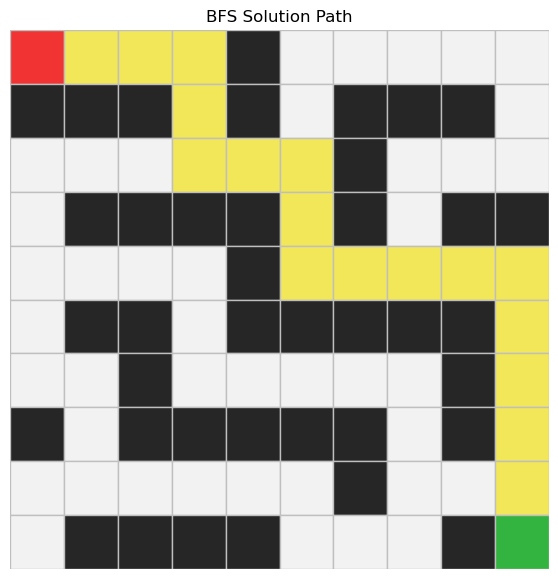

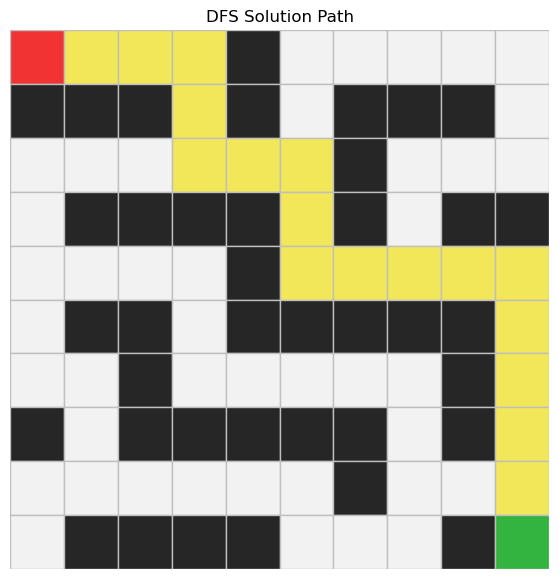

In [172]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)


# safe path extraction 
def extract_path(node):
    if node is None:
        return None

    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    return list(reversed(path))


bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=extract_path(bfs_result.solution),
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=extract_path(dfs_result.solution),
    title="DFS Solution Path",
)


Custom Map 1 Results:


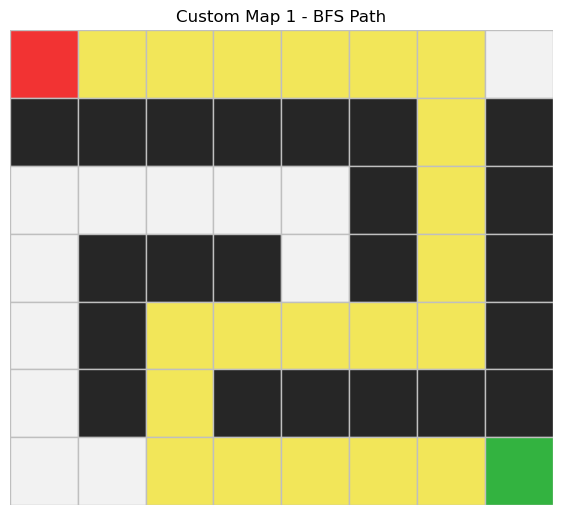

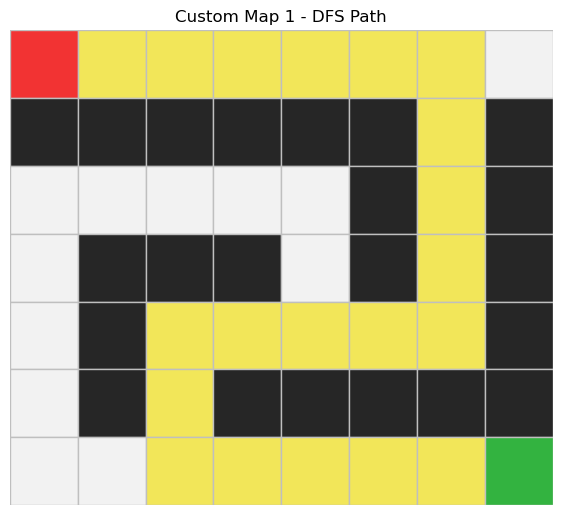

In [173]:
custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 1, 0, 1],
    [0, 1, 1, 1, 0, 1, 0, 1],
    [0, 1, 0, 0, 0, 0, 0, 1],
    [0, 1, 0, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (6, 7)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

print("\nCustom Map 1 Results:")
show_results(custom_results_1)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=extract_path(custom_results_1[0].solution),
    title="Custom Map 1 - BFS Path"
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=extract_path(custom_results_1[1].solution),
    title="Custom Map 1 - DFS Path"
)

In [174]:
def extract_path(node):
    if node is None:
        return None

    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    return list(reversed(path))

Custom Map 2 Results:


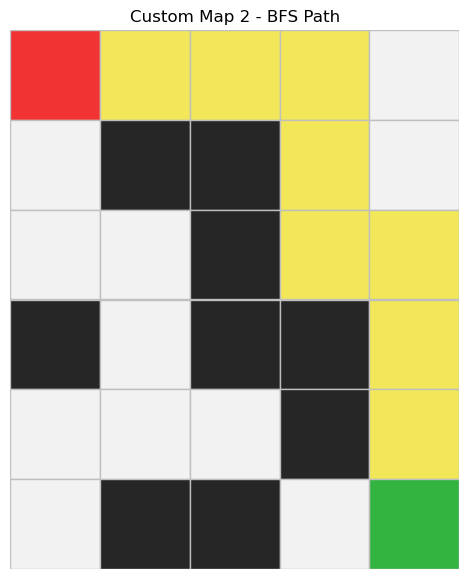

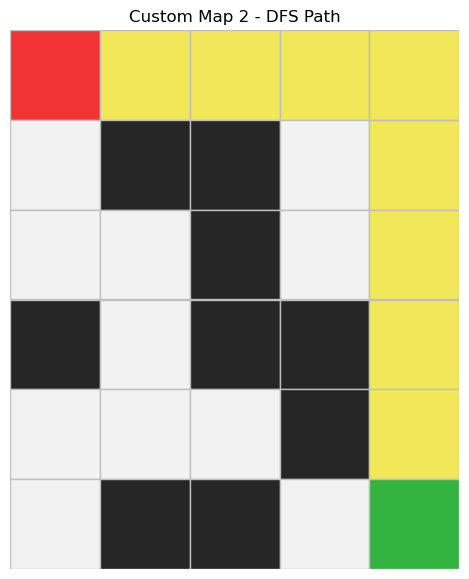

In [175]:
# Custom Map 2 -
custom_grid_2 = [
    [0, 0, 0, 0, 0],
    [0, 1, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 0, 1, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 1, 1, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (5, 4)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]

print("Custom Map 2 Results:")
show_results(custom_results_2)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=extract_path(custom_results_2[0].solution),
    title="Custom Map 2 - BFS Path"
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=extract_path(custom_results_2[1].solution),
    title="Custom Map 2 - DFS Path"
)

15.1 Problem Structuring

1. State: - This describes where the drone is located on the grid as represented by two coordinates: (row, column). 

2. Action - This defines the possible movements the drone can perform given its current location. The drone can move in any of the four cardinal directions (up, down, left, right). If it do not lead the drone over the edge of the grid or into an obstacle.

3. Result Function - This is the function that takes the current state and the action to produce the new state as a result of the action. 

15.2 BFS

1. FIFO Ques: FIFO Ques is used to explore the nodes by the order at which the nodes are discovered (oldest nodes first) and explore all nodes at that same depth before moving onto the next depth. 
2. Shortest Path: BFS finds a node by examining each possible path (to that node) and returning the shortest path with the least amount of moves to reach that particular node.

3. Purpose of Reached Set: The reached set is used to remember where the algorithm has already been to avoid getting stuck in loops or looking up previously explored nodes. 

15.3 DFS
1. Why does DFS use a stack?
When searching using Depth First Search (DFS) you always are trying to go deeper, and therefore the stack maintains the last-node that DFS will expand.

2. Is DFS guaranteed to find the shortest path? Explain.
    The DFS does not guarantee that it will find the shortest path to the goal node. In some cases, it may find the goal node after having gone to great lengths down a lengthy path

3. Under what conditions can DFS use less memory than BFS?
    When the search space is wide, DFS requires less memory than Breadth First Search (BFS), because it only keeps track of the current path instead of all of the nodes at each level in the search.
4. Under what conditions can DFS perform badly?
    Performance of DFS will be adversely affected when the goal is found deep or on a branch that goes down a long-length path. The performance of DFS can degrade significantly by taking a long time to find a lengthy path, or may become stuck in the process of trying to find one.

15.4 DLS
1. What happens when the depth limit is too small?
     The search will terminate early and possibly not find the goal at all.
2. What is the meaning of "cutoff"?
     The term indicates that the search is terminated through the use of a depth limit rather than because there are no more nodes.
3. How is DLS different from ordinary DFS?
    DLS is performed like DFS but with a limit on the maximum depth the algorithm will search; DFS has no such limit.
4. Why do we use path-cycle checking in DLS?
To prevent the search from going around in circles by re-visiting states and either wasting time or becoming completely stuck.

15.5 IDS
1. Why does IDS repeat DLS with increasing limits?
    To gradually find deeper levels until the goal is found.
2. Why can IDS be complete even though DLS with a small limit is not?
    IDS will increase the limit until any depth is reached.
3. Why does IDS use less memory than BFS?
    IDS only holds one path as DFS does, instead of holding all nodes in level.
4. What is the cost of repeatedly searching from the root?
    IDS will re-scan many nodes multiple times, resulting in more time being used.

15.6 Real-World Drone Context
        
1. In a real drone application, what might make one route safer or more practical than another?
    A safe route has no obstacles, less wind, shorter distance, and areas that provide better visibility for signals.
2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
    The best algorithm to calculate the fewest moves (all moves costing equally) is the breadth-first search (BFS) algorithm. This algorithm will find the shortest number of moves taken to reach the destination.
3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
    The best algorithm to limit how deep to search would be depth-limited search (DLS). This algorithm is designed so that if a predefined depth limit is reached, this algorithm will not search further
4. What limitations does this grid model have compared with real drone navigation?
    The grid model is too simplistic, as it does not take into account many real-world factors. For example, the grid model does not take into consideration factors such as wind, speed, battery life, altitude, moving obstacles, and continuous (non-grid based) movement